In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import random
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset
from trainer_class import Trainer

from ResNet import ResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)

Device: cuda


In [4]:
DATASET_PATH = r"/itf-fi-ml/shared/courses/IN3310/mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(class_names, class_filenames)

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=None)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=None)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=None)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=transform)

# --------------------------------------------------------------------------------------------------------------------------------

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, -1.0, 1.0)

# --------------------------------------------------------------------------------------------------------------------------------

model_ResNet = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet.parameters(), lr=1e-4)

trainer_ResNet = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 0.7620, acc: 0.710 | val loss: 0.8497, acc: 0.704, mean average precision (mAP): 0.833, AP per class: [0.79356324 0.9577859  0.78981167 0.85171191 0.79525209 0.80834523]
Epoch 02 | train loss: 0.4682, acc: 0.830 | val loss: 0.4953, acc: 0.819, mean average precision (mAP): 0.901, AP per class: [0.87280072 0.98114971 0.85982971 0.87840336 0.90953817 0.90482066]
Epoch 03 | train loss: 0.3363, acc: 0.876 | val loss: 0.6901, acc: 0.771, mean average precision (mAP): 0.870, AP per class: [0.83759099 0.93701015 0.86249691 0.86105524 0.92209513 0.79703067]
Epoch 04 | train loss: 0.2324, acc: 0.922 | val loss: 0.9992, acc: 0.720, mean average precision (mAP): 0.817, AP per class: [0.69535561 0.93361791 0.83766651 0.73638319 0.86065345 0.83731032]
Epoch 05 | train loss: 0.1884, acc: 0.938 | val loss: 1.0224, acc: 0.714, mean average precision (mAP): 0.842, AP per class: [0.80976879 0.95880283 0.73249576 0.8354603  0.85555591 0.86189721]
Epoch 06 | train loss: 0.1137, acc:

In [5]:
trainer_ResNet.evaluate(test_loader)

EpochStats(loss=0.8879654308160146, acc=0.7825732529163361, mAP=0.8778188093585385, AP_per_class=array([0.8794017 , 0.97240989, 0.83643034, 0.83402049, 0.89817978,
       0.84647065]))

In [ ]:
# Move results from GPU to memory
results_dict = trainer_ResNet.history

In [ ]:
# Clean as much as possible of the GPU memory
import gc
if 'trainer_ResNet' in globals():
    del trainer_ResNet

if 'model' in globals():
    del model_ResNet

# 2. Force Python to find and remove "orphaned" memory references
gc.collect()

# 3. IMPORTANT: Tell PyTorch to give the memory back to the GPU pool
# Without this, nvidia-smi will still show the memory as "Used"
torch.cuda.empty_cache()

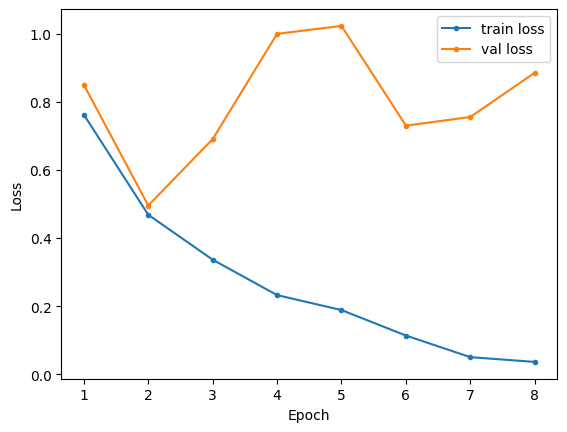

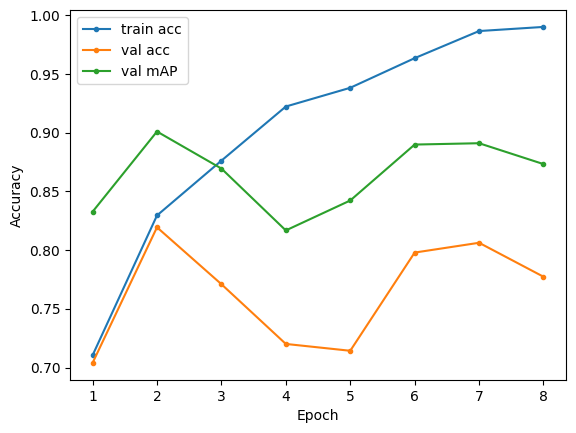

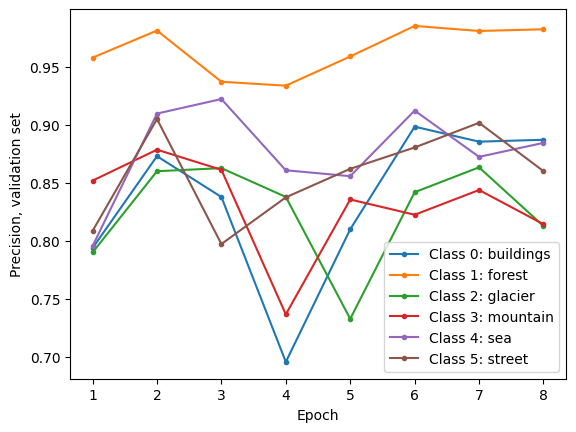

In [17]:
epochs_list = np.arange(1, num_epochs+1)

plt.plot(epochs_list, results_dict["train_loss"], '.-', label="train loss")
plt.plot(epochs_list, results_dict["val_loss"], '.-', label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(epochs_list, results_dict["train_acc"], '.-', label="train acc")
plt.plot(epochs_list, results_dict["val_acc"], '.-', label="val acc")
plt.plot(epochs_list, results_dict["val_mAP"], '.-', label="val mAP")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

hist_arr_val_AP_per_class = np.asarray(results_dict["val_AP_per_class"])
for class_number, class_name in enumerate(class_names):
    plt.plot(epochs_list, hist_arr_val_AP_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

plt.xlabel("Epoch")
plt.ylabel("Precision, validation set")
plt.legend()
plt.show()